In [5]:
# import numpy as np
# import pandas as pd
# from scipy.stats import norm

# # ==========================================
# # INPUT DISTRIBUTIONS
# # ==========================================
# def sample_pX(dist, n, sigma=0.2):
#     if dist == "A":
#         x = np.random.uniform(2,3, n)
#     elif dist == "B":
#         x = np.random.normal(0, sigma, n)
#     elif dist == "C":
#         x = np.random.normal(0.5, sigma, n)
#     elif dist == "D":
#         x = np.random.normal(1.0, sigma, n)
#     elif dist == "E":
#         which = np.random.binomial(1, 0.5, n)
#         x     = which * np.random.normal(0.3, sigma, n) + \
#                 (1 - which) * np.random.normal(0.7, sigma, n)
#     return np.clip(x, 0, 1)

# # ==========================================
# # MECHANISMS
# # ==========================================
# def make_s5():
#     alphas = np.random.dirichlet(np.ones(5))
#     mus    = np.random.uniform(0, 1, 5)
#     sigmas = np.random.uniform(0, 0.1, 5)
#     def s5(x):
#         result = np.zeros_like(x, dtype=float)
#         for i in range(5):
#             result += alphas[i] * norm.cdf(
#                 x, loc=mus[i], scale=sigmas[i] + 1e-6)
#         return result
#     return s5

# def apply_f(x, func, s5_fn=None):
#     if func == "a":  return np.cbrt(x)
#     elif func == "b": return np.sqrt(np.abs(x) + 1e-8)
#     elif func == "c": return x**2
#     elif func == "d": return x**3
#     elif func == "e": return s5_fn(x)

# # ==========================================
# # DATA GENERATION
# # ==========================================
# def generate_data(n=1000, px_dist="A", func="c",
#                   fault_magnitude=1.0, lam=0.1,
#                   sigma=0.2, seed=None):
#     """
#     Generate normal and faulty DataFrames.

#     Returns:
#         df_normal : DataFrame with columns [X, Y], normal state
#         df_faulty : DataFrame with columns [X, Y], faulty state
#                     fault injected at X (root cause)
#     """
#     if seed is not None:
#         np.random.seed(seed)

#     s5_fn = make_s5() if func == "e" else None

#     def make_df(fault_x):
#         x = sample_pX(px_dist, n, sigma=sigma) + fault_x
#         x = np.clip(x, 0, 1 + fault_x)
#         y = apply_f(x, func, s5_fn) + \
#             lam * np.random.normal(0, sigma, n)
#         return pd.DataFrame({"X": x, "Y": y})

#     df_normal = make_df(fault_x=0.0)
#     df_faulty = make_df(fault_x=fault_magnitude)

#     return df_normal, df_faulty


# # ==========================================
# # MAIN — configure here
# # ==========================================
# if __name__ == "__main__":

#     PX_DIST        = "A"    # A, B, C, D, E
#     FUNC           = "c"    # a, b, c, d, e
#     N              = 1000
#     FAULT_MAGNITUDE = 1.0
#     LAM            = 0.1
#     SIGMA          = 0.2
#     SEED           = 42

#     PX_NAMES = {
#         "A": "U(0,1)", "B": "N(0,σ²)", "C": "N(0.5,σ²)",
#         "D": "N(1,σ²)", "E": "GM([0.3,0.7])"
#     }
#     FUNC_NAMES = {
#         "a": "x^(1/3)", "b": "x^(1/2)", "c": "x²",
#         "d": "x³",      "e": "s5(x)"
#     }

#     normal, faulty = generate_data(
#         n              = N,
#         px_dist        = PX_DIST,
#         func           = FUNC,
#         fault_magnitude = FAULT_MAGNITUDE,
#         lam            = LAM,
#         sigma          = SIGMA,
#         seed           = SEED
#     )

#     print(f"p_X = {PX_NAMES[PX_DIST]},  f = {FUNC_NAMES[FUNC]}")
#     print(f"Fault magnitude = {FAULT_MAGNITUDE},  λ = {LAM},  σ = {SIGMA}")
#     print(f"\nNormal ({len(normal)} samples):")
#     print(normal.describe().round(4))
#     print(f"\nFaulty ({len(faulty)} samples):")
#     print(faulty.describe().round(4))
#     print(f"\nMean shift:")
#     print((faulty.mean() - normal.mean()).round(4))

In [3]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


RCD_PATH = "/home/local/ASURITE/aiquebal/rcd"
inc_path = Path(RCD_PATH) / "sock-shop-data" / "payment-cpu" / "1"

normal = pd.read_csv(inc_path / "normal.csv")
faulty = pd.read_csv(inc_path / "anomalous.csv")



feature_indices = [i for i in range(normal.shape[1]- 1)]
cols = [c for c in normal.columns if c != "time"]
feat = [cols[i] for i in feature_indices]
feat[:13]

['carts_cpu',
 'carts-db_cpu',
 'catalogue_cpu',
 'catalogue-db_cpu',
 'front-end_cpu',
 'orders_cpu',
 'orders-db_cpu',
 'payment_cpu',
 'queue-master_cpu',
 'rabbitmq_cpu',
 'shipping_cpu',
 'user_cpu',
 'user-db_cpu']

In [4]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
from pathlib import Path
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA


RCD_PATH = "/home/local/ASURITE/aiquebal/rcd"
inc_path = Path(RCD_PATH) / "sock-shop-data" / "payment-cpu" / "1"

normal = pd.read_csv(inc_path / "normal.csv")
faulty = pd.read_csv(inc_path / "anomalous.csv")



feature_indices = [i for i in range(normal.shape[1]- 1)]
cols = [c for c in normal.columns if c != "time"]
feat = [cols[i] for i in feature_indices]

feat = feat[:13]
preprocessing = True

if preprocessing == True:

    # raw arrays
    Xn = normal[feat].to_numpy(np.float32)
    Xf = faulty[feat].to_numpy(np.float32)

    # # 1) log1p
    # Xn = np.log1p(np.clip(Xn, a_min=0.0, a_max=None))
    # Xf = np.log1p(np.clip(Xf, a_min=0.0, a_max=None))

    # # 2) add small noise with SNR relative to Xn
    # snr_db = 50.0
    # signal_power = np.mean(Xn ** 2)
    # noise_power = signal_power / (10 ** (snr_db / 10.0))
    # noise_std = np.sqrt(noise_power)

    # Xn = Xn + noise_std * np.random.randn(*Xn.shape)
    # Xf = Xf + noise_std * np.random.randn(*Xf.shape)

    # 3) standardize on normal only
    scaler = MinMaxScaler()
    scaler.fit(Xn)

    # For features with no variability in normal:
    # set scale to 1.0 (pass-through), not a floor
    degenerate = scaler.data_range_ < 1e-1
    scaler.data_range_[degenerate] = 1.0
    scaler.scale_[degenerate] = 1.0
    # Center at zero but don't scale
    scaler.min_[degenerate] = -scaler.data_min_[degenerate]

    Xn = scaler.transform(Xn)
    Xf = scaler.transform(Xf)

    # # 4) optional whitening
    # whitener = PCA(whiten=True)
    # Xn = whitener.fit_transform(Xn)
    # Xf = whitener.transform(Xf)

    # plt.plot(Xn)
    # plt.plot(Xf)
# feat

In [22]:
np.set_printoptions(precision=4, suppress=True)
np.array(Xn.mean(axis=0)), np.array(Xf.mean(axis=0))    

(array([0.3971, 0.9557, 0.7512, 0.0465, 0.7631, 0.5996, 0.5608, 0.027 ,
        0.6768, 0.712 , 0.6077, 0.5764, 0.3771], dtype=float32),
 array([ 0.9334,  0.1557,  0.9762,  0.1002,  1.5978,  2.0861,  0.726 ,
        94.9222,  1.5807,  0.9764,  1.7411,  3.0865,  0.4657],
       dtype=float32))

In [17]:
# # Xf = faulty[feat].to_numpy(np.float32)
# # Xf = np.log1p(np.clip(Xf, a_min=0.0, a_max=None))
# # Xf = Xf + noise_std * np.random.randn(*Xf.shape)
# # Xf = scaler.transform(Xf)
# np.where(np.array(feat) == "orders_cpu")
# # # # feat = 'user_cpu'
# # # normal[feat]['user_cpu'], faulty[feat]['user_cpu']
# # np.sort(torch.randint(0, len(Xf), (batch,)))
# index = 0
# Xn[:,index], Xf[:,index]
# plt.hist(Xn[:,index], bins=50, alpha=0.5, label='Normal')
# plt.hist(Xf[:,index], bins=50, alpha=0.5, label='Faulty')
# plt.legend()
# plt.title('Distribution of first feature (after preprocessing)')
# plt.xlabel('Value')
# plt.ylabel('Frequency')
# plt.show() 

In [23]:
Xn = torch.tensor(Xn, dtype=torch.float32)
Xf = torch.tensor(Xf, dtype=torch.float32)

class Flow(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2 * d + 1, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, d),
        )

    def forward(self, xt, t, x0):
        return self.net(torch.cat([xt, t, x0], dim=1))

d = Xn.shape[1]
model = Flow(d=d)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

batch = 64

for step in range(20000):
    idx0 = torch.randint(0, len(Xf), (batch,))
    idx1 = torch.randint(0, len(Xn), (batch,))

    x0 = Xf[idx0]
    x1 = Xn[idx1]
    t = torch.rand(batch, 1)

    xt = (1 - t) * x0 + t * x1
    v_target = x1 - x0
    v_pred = model(xt, t, x0)

    loss = ((v_pred - v_target) ** 2).mean()

    opt.zero_grad()
    loss.backward()
    opt.step()

    if step % 2000 == 0:
        print(step, loss.item())

@torch.no_grad()

@torch.no_grad()
def translate(X, steps=50, noise_scale=0.1):
    # raw -> log1p -> standardize
    x0 = np.log1p(np.clip(X, a_min=0.0, a_max=None))
    x0 = scaler.transform(x0)

    x0 = torch.tensor(x0, dtype=torch.float32)
    x = x0.clone()
    dt = 1.0 / steps

    for i in range(steps):
        t = torch.full((x.shape[0], 1), i / steps, dtype=torch.float32)
        v = model(x, t, x0)

        # stochastic term in standardized log space
        noise = noise_scale * np.sqrt(dt) * torch.randn_like(x)

        x = x + dt * v + noise

    # standardized -> log space -> raw
    x = scaler.inverse_transform(x.numpy())
    x = np.expm1(x)
    return np.clip(x, a_min=0.0, a_max=None)

Xt = translate(Xf.numpy(), steps=50, noise_scale=0.5)

0 689.9427490234375
2000 0.5388761162757874
4000 0.16376957297325134
6000 0.10472925752401352
8000 0.0875161811709404
10000 0.06343429535627365
12000 0.058404721319675446
14000 0.05693763867020607
16000 0.03431158512830734
18000 0.034983079880476


In [19]:
# # ============================================================
# # FLOW MODEL — unconditional (consistent with Daniusis)
# # ============================================================

# class FlowModel(nn.Module):
#     def __init__(self, d):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(d + 1, 128),
#             nn.ELU(),
#             nn.Linear(128, 128),
#             nn.ELU(),
#             nn.Linear(128, 128),
#             nn.ELU(),
#             nn.Linear(128, d),
#         )

#     def forward(self, x, t):
#         return self.net(torch.cat([x, t], dim=1))

# # ============================================================
# # TRAINING — faulty → normal, unconditional
# # ============================================================

# d = Xn.shape[1]
# model = FlowModel(d=d)
# opt = torch.optim.Adam(model.parameters(), lr=1e-3)
# sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=20000)

# batch = 128

# for step in range(10000):
#     idx0 = torch.randint(0, len(Xf), (batch,))
#     idx1 = torch.randint(0, len(Xn), (batch,))

#     x0 = Xf[idx0]   # faulty (t=0)
#     x1 = Xn[idx1]   # normal (t=1)
#     t = torch.rand(batch, 1)

#     x_t = (1 - t) * x0 + t * x1      # faulty → normal
#     v_target = x1 - x0                # normal - faulty

#     loss = nn.functional.mse_loss(model(x_t, t), v_target)

#     opt.zero_grad()
#     loss.backward()
#     opt.step()
#     sched.step()

#     if step % 2000 == 0:
#         print(step, loss.item())

# # ============================================================
# # SCORING — velocity at t=0 (faulty state)
# # ============================================================

# model.eval()
# with torch.no_grad():
#     t = torch.ones((len(Xf), 1)) * 0.5
#     x_t = (1 - t) * Xf + t * Xn[:len(Xf)]
#     V = model(x_t, t).cpu().numpy()

# results = []
# for i, col in enumerate(feat):
#     v = V[:, i]
#     v = v[np.isfinite(v)]
#     sigma = float(np.std(v)) if v.size else 0.0

#     if v.size < 2 or sigma < 1e-8:
#         results.append({"feature": col, "H": -np.inf, 
#                         "sigma": sigma, "R": -np.inf})
#         continue

#     h = compute_entropy(v)
#     r = (h - np.log(sigma) 
#          if np.isfinite(h) and sigma > 1e-8 else -np.inf)
#     results.append({
#         "feature": col,
#         "H": round(h, 4) if np.isfinite(h) else -np.inf,
#         "sigma": round(sigma, 4),
#         "R": round(r, 4) if np.isfinite(r) else -np.inf,
#     })

# df_r = pd.DataFrame(results).sort_values(

#     "H", ascending=False
# ).reset_index(drop=True)
# df_r.index += 1

# print(df_r.to_string())

# print(f"\n  Pred (H): {df_r.iloc[0]['feature']}")

In [20]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Xt is already in raw units if translate() returns inverse-transformed + expm1 output
# Xn_raw = np.expm1(scaler.inverse_transform(Xn.numpy()))
# Xf_raw = np.expm1(scaler.inverse_transform(Xf.numpy()))

# n_feat = len(feat)
# fig, axes = plt.subplots(n_feat, 2, figsize=(8, 4 * n_feat))
# axes = np.atleast_2d(axes)

# def plot_hist(ax, data, label):
#     data = np.asarray(data)
#     data = data[np.isfinite(data)]
#     if len(data) == 0:
#         return
#     if len(np.unique(data)) < 2 or np.ptp(data) == 0:
#         ax.axvline(data[0], label=label)
#     else:
#         bins = min(30, max(5, len(np.unique(data))))
#         ax.hist(data, bins=bins, density=True, alpha=0.5, label=label)

# for idx in range(n_feat):
#     ax = axes[idx, 0]
#     plot_hist(ax, Xn_raw[:, idx], "normal")
#     plot_hist(ax, Xt[:, idx], "translated")
#     ax.set_title(f"{feat[idx]}\nnormal vs translated")
#     ax.legend()

#     ax = axes[idx, 1]
#     plot_hist(ax, Xf_raw[:, idx], "faulty")
#     plot_hist(ax, Xt[:, idx], "translated")
#     ax.set_title(f"{feat[idx]}\nfaulty vs translated")
#     ax.legend()

# plt.tight_layout()
# plt.show()

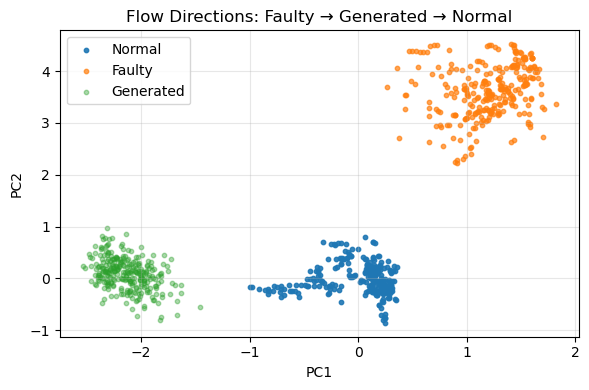

In [24]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torch
import numpy as np

@torch.no_grad()
def visualize_flow_pca(net, X_normal_std, X_faulty_std, X_faulty_raw, translate_fn, scaler, n_components=2, device=None, show_plot=True):
    if device is None:
        device = next(net.parameters()).device

    X_normal_std = X_normal_std.to(device, dtype=torch.float32)
    X_faulty_std = X_faulty_std.to(device, dtype=torch.float32)

    Xn_cpu = X_normal_std.detach().cpu().numpy()
    Xf_cpu = X_faulty_std.detach().cpu().numpy()

    pca = PCA(n_components=n_components)
    Z_normal = pca.fit_transform(Xn_cpu)
    Z_faulty = pca.transform(Xf_cpu)

    X_generated_raw = translate_fn(X_faulty_raw)
    X_generated_std = scaler.transform(np.log1p(np.clip(X_generated_raw, a_min=0.0, a_max=None)))
    Z_gen = pca.transform(X_generated_std)

    if show_plot:
        plt.figure(figsize=(6, 4))
        plt.scatter(Z_normal[:, 0], Z_normal[:, 1], s=10, alpha=0.9, label="Normal")
        plt.scatter(Z_faulty[:, 0], Z_faulty[:, 1], s=10, alpha=0.7, label="Faulty")
        plt.scatter(Z_gen[:, 0], Z_gen[:, 1], s=10, alpha=0.4, label="Generated")
        plt.title("Flow Directions: Faulty → Generated → Normal")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return X_generated_raw, Z_normal, Z_faulty, Z_gen

X_faulty_raw = faulty[feat].to_numpy(np.float32)

X_generated, Z_normal, Z_faulty, Z_gen = visualize_flow_pca(
    model, Xn, Xf, X_faulty_raw, translate, scaler, show_plot=True
)

In [25]:
from scipy.stats import gaussian_kde
import numpy as np
import pandas as pd
import torch

def compute_entropy(v):
    v = np.asarray(v, dtype=np.float64)
    v = v[np.isfinite(v)]
    if v.size < 2:
        return -np.inf
    if np.std(v) < 1e-8:
        return -np.inf
    try:
        kde = gaussian_kde(v)
        return float(np.mean(-kde.logpdf(v)))
    except Exception:
        return -np.inf

device = next(model.parameters()).device

model.eval()
with torch.no_grad():
    x0 = Xf.to(device=device, dtype=torch.float32)
    t0 = torch.zeros((len(x0), 1), device=device, dtype=torch.float32)
    xt = x0.clone()
    V = model(xt, t0, x0).detach().cpu().numpy()

# model.eval()
# with torch.no_grad():
#     n = min(len(Xn), len(Xf))
#     x0 = Xf[:n].to(device=device, dtype=torch.float32)
#     x1 = Xn[:n].to(device=device, dtype=torch.float32)
#     t = torch.ones((n, 1), device=device, dtype=torch.float32) * 0.0
#     xt = (1 - t) * x0 + t * x1
#     V = model(xt, t, x0).detach().cpu().numpy()

results = []
for i, col in enumerate(feat):
    v = V[:, i]
    v = v[np.isfinite(v)]
    sigma = float(np.std(v)) if v.size else 0.0

    if v.size < 2 or sigma < 1e-8:
        results.append({"feature": col, "H": -np.inf, "sigma": sigma, "R": -np.inf})
        continue

    h = compute_entropy(v)
    r = h - np.log(sigma) if np.isfinite(h) and sigma > 1e-8 else -np.inf
    results.append({
        "feature": col,
        "H": round(h, 4) if np.isfinite(h) else -np.inf,
        "sigma": round(sigma, 4),
        "R": round(r, 4) if np.isfinite(r) else -np.inf,
    })

df_r = pd.DataFrame(results).sort_values("H", ascending=False).reset_index(drop=True)
df_r.index += 1

print(f"\n{'='*62}")
print("  ROOT CAUSE RANKING — R(Z) = H(v) - log(sigma)")
print("  Incident: carts-cpu / 1")
print("  True RC : carts_cpu")
print(f"{'='*62}")
print(df_r.to_string())
print(f"\n  PREDICTED ROOT CAUSE: {df_r.iloc[0]['feature']}")
correct = df_r.iloc[0]["feature"] == "carts_cpu"
print(f"  RESULT            : {'✓ Correct' if correct else '✗ Wrong'}")
print(f"{'='*62}")


  ROOT CAUSE RANKING — R(Z) = H(v) - log(sigma)
  Incident: carts-cpu / 1
  True RC : carts_cpu
             feature       H    sigma       R
1        payment_cpu  2.9626  12.5574  0.4323
2           user_cpu  0.6732   0.6099  1.1677
3   queue-master_cpu  0.6608   0.4996  1.3548
4         orders_cpu  0.6092   0.5041  1.2941
5       shipping_cpu -0.0650   0.2376  1.3722
6      front-end_cpu -0.1693   0.2830  1.0930
7      orders-db_cpu -0.3943   0.1899  1.2672
8       carts-db_cpu -0.4335   0.2010  1.1711
9      catalogue_cpu -0.5404   0.2063  1.0380
10         carts_cpu -1.0199   0.1046  1.2381
11       user-db_cpu -1.1234   0.0835  1.3600
12      rabbitmq_cpu -1.2284   0.0782  1.3201
13  catalogue-db_cpu -3.1556   0.0109  1.3602

  PREDICTED ROOT CAUSE: payment_cpu
  RESULT            : ✗ Wrong


In [5]:
# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import gaussian_kde

# ============================================================
# DATA LOADING
# ============================================================

condition = "user-cpu"

RCD_PATH = "/home/local/ASURITE/aiquebal/rcd"
inc_path = Path(RCD_PATH) / "sock-shop-data" / condition  / "1"

normal = pd.read_csv(inc_path / "normal.csv")
faulty = pd.read_csv(inc_path / "anomalous.csv")

feat = [c for c in normal.columns if c != "time"]
feat[13:26]

['carts_mem',
 'carts-db_mem',
 'catalogue_mem',
 'catalogue-db_mem',
 'front-end_mem',
 'orders_mem',
 'orders-db_mem',
 'payment_mem',
 'queue-master_mem',
 'rabbitmq_mem',
 'shipping_mem',
 'user_mem',
 'user-db_mem']

In [22]:
# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import gaussian_kde

# ============================================================
# DATA LOADING
# ============================================================

condition = "orders-cpu"

RCD_PATH = "/home/local/ASURITE/aiquebal/rcd"
inc_path = Path(RCD_PATH) / "sock-shop-data" / condition  / "2"

normal = pd.read_csv(inc_path / "normal.csv")
faulty = pd.read_csv(inc_path / "anomalous.csv")

feat = [c for c in normal.columns if c != "time"]
feat = feat[:13]  # select first 13 features for analysis for cpu 
# feat = feat[13:26] # select next 13 features for analysis for mem
# ============================================================
# PREPROCESSING
# ============================================================

Xn = normal[feat].to_numpy(np.float32)
Xf = faulty[feat].to_numpy(np.float32)

# 1) Memory → MB
for i, c in enumerate(feat):
    if c.endswith("_mem"):
        Xn[:, i] /= 1e6
        Xf[:, i] /= 1e6

# 2) Log1p
# Xn = np.log1p(np.clip(Xn, a_min=0.0, a_max=None))
# Xf = np.log1p(np.clip(Xf, a_min=0.0, a_max=None))

# 3) Noise injection
# snr_db = 50.0
# signal_power = np.mean(Xn ** 2)
# noise_power = signal_power / (10 ** (snr_db / 10.0))
# noise_std = np.sqrt(noise_power)
# Xn = Xn + noise_std * np.random.randn(*Xn.shape).astype(np.float32)
# Xf = Xf + noise_std * np.random.randn(*Xf.shape).astype(np.float32)

# 4) MinMaxScaler fit on normal, pass-through for degenerate
scaler = MinMaxScaler()
scaler.fit(Xn)

degenerate = scaler.data_range_ < 1e-4
scaler.data_range_[degenerate] = 1.0
scaler.scale_[degenerate] = 1.0
scaler.min_[degenerate] = -scaler.data_min_[degenerate]

Xn = scaler.transform(Xn)
Xf = scaler.transform(Xf)

Xn = torch.tensor(Xn, dtype=torch.float32)
Xf = torch.tensor(Xf, dtype=torch.float32)

In [10]:
# position = feat.index(condition.replace("-", "_"))
# np.array(Xn.mean(axis=0))[position], np.array(Xf.mean(axis=0))[position]    

In [11]:
np.set_printoptions(precision=4, suppress=True)
np.array(Xn.mean(axis=0)), np.array(Xf.mean(axis=0)) 

/tmp/ipykernel_3377397/1226768.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.array(Xn.mean(axis=0)), np.array(Xf.mean(axis=0))


(array([0.3093, 0.3728, 0.2975, 0.    , 0.5752, 0.3211, 0.3282, 0.5851,
        0.0445, 0.1145, 0.0872, 0.1848, 0.5007], dtype=float32),
 array([   -3.4951,  -229.1246,    -9.4579,     0.0082,   -16.3595,
           -9.7655,  -829.0859,   -13.3268, -8407.523 ,    -7.1758,
           -8.9734,   -16.8058,  -383.8712], dtype=float32))

In [ ]:

# ============================================================
# MODEL — unconditional
# ============================================================

class FlowModel(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d + 1, 128),
            nn.ELU(),
            nn.Linear(128, 128),
            nn.ELU(),
            nn.Linear(128, 128),
            nn.ELU(),
            nn.Linear(128, d),
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

# ============================================================
# TRAINING — faulty → normal
# ============================================================

d = Xn.shape[1]
model = FlowModel(d=d)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=20000)

batch = 128

for step in range(20000):
    idx0 = torch.randint(0, len(Xf), (batch,))
    idx1 = torch.randint(0, len(Xn), (batch,))

    x0 = Xf[idx0]
    x1 = Xn[idx1]
    t = torch.rand(batch, 1)

    x_t = (1 - t) * x0 + t * x1
    v_target = x1 - x0

    loss = nn.functional.mse_loss(model(x_t, t), v_target)

    opt.zero_grad()
    loss.backward()
    opt.step()
    sched.step()

    if step % 2000 == 0:
        print(step, loss.item())

# ============================================================
# SCORING — velocity at t=0
# ============================================================

def compute_entropy(v):
    v = np.asarray(v, dtype=np.float64)
    v = v[np.isfinite(v)]
    if v.size < 2:
        return -np.inf
    if np.std(v) < 1e-8:
        return -np.inf
    try:
        kde = gaussian_kde(v)
        return float(np.mean(-kde.logpdf(v)))
    except Exception:
        return -np.inf

model.eval()
with torch.no_grad():
    t0 = torch.ones((len(Xf), 1)) * 0.75
    V = model(Xf, t0).cpu().numpy()

# Un-standardize velocities
V = V * scaler.data_range_[None, :]

results = []
for i, col in enumerate(feat):
    v = V[:, i]
    v = v[np.isfinite(v)]
    sigma = float(np.std(v)) if v.size else 0.0

    if v.size < 2 or sigma < 1e-8:
        results.append({"feature": col, "H": -np.inf,
                        "sigma": sigma, "R": -np.inf})
        continue

    h = compute_entropy(v)
    r = (h - np.log(sigma)
         if np.isfinite(h) and sigma > 1e-8 else -np.inf)
    results.append({
        "feature": col,
        "H": round(h, 4) if np.isfinite(h) else -np.inf,
        "sigma": round(sigma, 4),
        "R": round(r, 4) if np.isfinite(r) else -np.inf,
    })

df_r = pd.DataFrame(results).sort_values(
    "H", ascending=False
).reset_index(drop=True)
df_r.index += 1



true_rc = condition.replace("-", "_")

print(f"\n{'='*62}")
print(f"  Incident: {condition} / 1")
print(f"  True RC : {true_rc}")
print(f"{'='*62}")
print(df_r.to_string())
print(f"\n  Pred (H): {df_r.iloc[0]['feature']}")
correct = df_r.iloc[0]["feature"] == true_rc
print(f"  Result  : {'✓' if correct else '✗'}")
print(f"{'='*62}")

0 2162.83447265625
2000 22.990306854248047
4000 3.3605058193206787
6000 1.5900485515594482
8000 6.073775768280029
10000 0.7920820713043213
12000 1.2337837219238281
14000 1.0162392854690552
16000 1.3571116924285889
18000 0.7015780806541443

  Incident: orders-cpu / 1
  True RC : orders_cpu
             feature       H    sigma       R
1         orders_cpu  2.8524  11.7671  0.3871
2       carts-db_cpu  0.4584   0.5662  1.0272
3      front-end_cpu -1.3313   0.1484  0.5767
4          carts_cpu -2.4897   0.0338  0.8988
5           user_cpu -2.7794   0.0250  0.9083
6      catalogue_cpu -3.1222   0.0133  1.1949
7        user-db_cpu -3.4063   0.0102  1.1745
8       rabbitmq_cpu -3.7314   0.0109  0.7888
9      orders-db_cpu -4.2671   0.0041  1.2393
10      shipping_cpu -4.6209   0.0032  1.1210
11  queue-master_cpu -4.6473   0.0036  0.9865
12       payment_cpu -4.8996   0.0050  0.4024
13  catalogue-db_cpu -4.9923   0.0021  1.1651

  Pred (H): orders_cpu
  Result  : ✓


## Benchmarking

In [29]:
device = 'cpu'

In [33]:
# ============================================================
# BLOCK 1: Imports and Configuration
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import gaussian_kde

RCD_PATH = "/home/local/ASURITE/aiquebal/rcd"
SOCK_PATH = Path(RCD_PATH) / "sock-shop-data"

N_SEEDS = 10
N_STEPS = 10000
BATCH = 128

# ============================================================
# BLOCK 2: Core Functions
# ============================================================

class FlowModel(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d + 1, 128),
            nn.ELU(),
            nn.Linear(128, 128),
            nn.ELU(),
            nn.Linear(128, 128),
            nn.ELU(),
            nn.Linear(128, d),
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))


def compute_entropy(v):
    v = np.asarray(v, dtype=np.float64)
    v = v[np.isfinite(v)]
    if v.size < 2:
        return -np.inf
    if np.std(v) < 1e-8:
        return -np.inf
    try:
        kde = gaussian_kde(v)
        return float(np.mean(-kde.logpdf(v)))
    except Exception:
        return -np.inf


def run_single(condition, scenario, seed=42):
    """
    Full pipeline for one incident.
    Selects CPU or MEM features based on condition name.
    """
    np.random.seed(seed)
    torch.manual_seed(seed)

    inc_path = SOCK_PATH / condition / str(scenario)
    if not inc_path.exists():
        return None

    # --- Load ---
    normal = pd.read_csv(inc_path / "normal.csv")
    faulty = pd.read_csv(inc_path / "anomalous.csv")

    all_feat = [c for c in normal.columns if c != "time"]

    # --- Select features by fault type ---
    fault_type = condition.split("-")[-1]  # "cpu" or "mem"
    if fault_type == "cpu":
        feat = [c for c in all_feat if c.endswith("_cpu")]
    elif fault_type == "mem":
        feat = [c for c in all_feat if c.endswith("_mem")]
    else:
        feat = all_feat

    true_rc = condition.replace("-", "_")

    # --- Preprocess ---
    Xn = normal[feat].to_numpy(np.float32)
    Xf = faulty[feat].to_numpy(np.float32)

    # Memory → MB
    if fault_type == "mem":
        Xn /= 1e6
        Xf /= 1e6

    # MinMaxScaler fit on normal, pass-through degenerate
    scaler = MinMaxScaler()
    scaler.fit(Xn)

    degenerate = scaler.data_range_ < 1e-4
    scaler.data_range_[degenerate] = 1.0
    scaler.scale_[degenerate] = 1.0
    scaler.min_[degenerate] = -scaler.data_min_[degenerate]

    Xn = scaler.transform(Xn)
    Xf = scaler.transform(Xf)

    Xn = torch.tensor(Xn, dtype=torch.float32)
    Xf = torch.tensor(Xf, dtype=torch.float32)

    # --- Train ---
    d = Xn.shape[1]
    model = FlowModel(d=d)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=N_STEPS
    )

    for step in range(N_STEPS):
        idx0 = torch.randint(0, len(Xf), (BATCH,))
        idx1 = torch.randint(0, len(Xn), (BATCH,))
        x0 = Xf[idx0]
        x1 = Xn[idx1]
        t = torch.rand(BATCH, 1)
        x_t = (1 - t) * x0 + t * x1
        v_target = x1 - x0
        loss = nn.functional.mse_loss(model(x_t, t), v_target)
        opt.zero_grad()
        loss.backward()
        opt.step()
        sched.step()

    # --- Score at t=0 ---
    model.eval()
    with torch.no_grad():
        # t0 = torch.zeros((len(Xf), 1))
        t0 = torch.ones(len(Xf), 1).to(device) * 0.5
        V = model(Xf, t0).cpu().numpy()

    # Un-scale velocities
    V = V * scaler.data_range_[None, :]

    results = []
    for i, col in enumerate(feat):
        v = V[:, i]
        v = v[np.isfinite(v)]
        sigma = float(np.std(v)) if v.size else 0.0
        if v.size < 2 or sigma < 1e-8:
            results.append({"feature": col, "H": -np.inf,
                            "sigma": sigma, "R": -np.inf})
            continue
        h = compute_entropy(v)
        r = (h - np.log(sigma)
             if np.isfinite(h) and sigma > 1e-8
             else -np.inf)
        results.append({
            "feature": col,
            "H": round(h, 4) if np.isfinite(h) else -np.inf,
            "sigma": round(sigma, 4),
            "R": round(r, 4) if np.isfinite(r) else -np.inf,
        })

    df = pd.DataFrame(results)
    ranked_H = df.sort_values("H", ascending=False
                              )["feature"].tolist()
    ranked_R = df.sort_values("R", ascending=False
                              )["feature"].tolist()

    return {
        "condition": condition,
        "fault_type": fault_type,
        "scenario": scenario,
        "seed": seed,
        "true_rc": true_rc,
        "pred_H": ranked_H[0],
        "pred_R": ranked_R[0],
        "AC1_H": true_rc in ranked_H[:1],
        "AC3_H": true_rc in ranked_H[:3],
        "AC5_H": true_rc in ranked_H[:5],
        "AC1_R": true_rc in ranked_R[:1],
        "AC3_R": true_rc in ranked_R[:3],
        "AC5_R": true_rc in ranked_R[:5],
    }

In [34]:
# ============================================================
# BLOCK 3: Run Benchmark — CPU and MEM separately
# ============================================================

cpu_conditions = sorted([
    d.name for d in SOCK_PATH.iterdir()
    if d.is_dir() and d.name.endswith("-cpu")
])

mem_conditions = sorted([
    d.name for d in SOCK_PATH.iterdir()
    if d.is_dir() and d.name.endswith("-mem")
])

print(f"CPU conditions: {cpu_conditions}")
print(f"MEM conditions: {mem_conditions}")

all_results = []

for conditions, label in [(cpu_conditions, "CPU"),
                           (mem_conditions, "MEM")]:
    print(f"\n{'█'*60}")
    print(f"  Running {label} experiments")
    print(f"{'█'*60}")

    for condition in conditions:
        scenarios = sorted([
            int(d.name) for d in (SOCK_PATH / condition).iterdir()
            if d.is_dir() and d.name.isdigit()
        ])

        for scenario in scenarios:
            for seed_idx in range(N_SEEDS):
                seed = seed_idx * 1000 + scenario

                print(f"  {condition} / {scenario} / "
                      f"seed {seed_idx+1}/{N_SEEDS} ... ",
                      end="", flush=True)

                try:
                    result = run_single(condition, scenario, seed)

                    if result is None:
                        print("SKIP")
                        continue

                    all_results.append(result)

                    h_sym = "✓" if result["AC1_H"] else "✗"
                    r_sym = "✓" if result["AC1_R"] else "✗"
                    print(f"H:{result['pred_H']} {h_sym}  "
                          f"R:{result['pred_R']} {r_sym}")

                except Exception as e:
                    print(f"ERROR: {e}")
                    continue

df_all = pd.DataFrame(all_results)
df_all.to_csv("sockshop_full_results.csv", index=False)
print(f"\nSaved {len(df_all)} results")

CPU conditions: ['carts-cpu', 'catalogue-cpu', 'orders-cpu', 'payment-cpu', 'user-cpu']
MEM conditions: ['carts-mem', 'catalogue-mem', 'orders-mem', 'payment-mem', 'user-mem']

████████████████████████████████████████████████████████████
  Running CPU experiments
████████████████████████████████████████████████████████████
  carts-cpu / 1 / seed 1/10 ... H:carts-db_cpu ✗  R:rabbitmq_cpu ✗
  carts-cpu / 1 / seed 2/10 ... H:carts-db_cpu ✗  R:user_cpu ✗
  carts-cpu / 1 / seed 3/10 ... H:carts-db_cpu ✗  R:carts-db_cpu ✗
  carts-cpu / 1 / seed 4/10 ... H:carts-db_cpu ✗  R:orders-db_cpu ✗
  carts-cpu / 1 / seed 5/10 ... H:carts-db_cpu ✗  R:orders-db_cpu ✗
  carts-cpu / 1 / seed 6/10 ... H:carts-db_cpu ✗  R:catalogue-db_cpu ✗
  carts-cpu / 1 / seed 7/10 ... H:carts-db_cpu ✗  R:user-db_cpu ✗
  carts-cpu / 1 / seed 8/10 ... H:carts-db_cpu ✗  R:shipping_cpu ✗
  carts-cpu / 1 / seed 9/10 ... H:carts-db_cpu ✗  R:catalogue-db_cpu ✗
  carts-cpu / 1 / seed 10/10 ... H:carts-db_cpu ✗  R:orders-db_cpu 

In [35]:
# ============================================================
# BLOCK 4: Results — CPU and MEM separately
# ============================================================

print(f"\n{'█'*70}")
print(f"  SOCK-SHOP BENCHMARK — FULL RESULTS")
print(f"  {len(df_all)} total runs")
print(f"{'█'*70}")

for fault_type, label in [("cpu", "CPU HOG"), ("mem", "MEM LEAK")]:
    subset = df_all[df_all["fault_type"] == fault_type]
    if len(subset) == 0:
        continue

    print(f"\n{'─'*70}")
    print(f"  {label}")
    print(f"{'─'*70}")

    # Overall for this fault type
    for c in ["H", "R"]:
        ac1 = subset[f"AC1_{c}"].mean() * 100
        ac3 = subset[f"AC3_{c}"].mean() * 100
        ac5 = subset[f"AC5_{c}"].mean() * 100
        print(f"  {c}: AC@1={ac1:.1f}%  AC@3={ac3:.1f}%  "
              f"AC@5={ac5:.1f}%")

    # Per-condition
    print(f"\n  {'Condition':<20} "
          f"{'AC@1':>6} {'AC@3':>6} {'AC@5':>6}  "
          f"{'AC@1':>6} {'AC@3':>6} {'AC@5':>6}  "
          f"{'Runs':>5}")
    print(f"  {'':20} "
          f"{'───── H ─────':^18}  "
          f"{'───── R ─────':^18}")
    print(f"  {'-'*68}")

    conditions = sorted(subset["condition"].unique())
    for condition in conditions:
        s = subset[subset["condition"] == condition]
        print(f"  {condition:<20} "
              f"{s['AC1_H'].mean()*100:>5.1f}% "
              f"{s['AC3_H'].mean()*100:>5.1f}% "
              f"{s['AC5_H'].mean()*100:>5.1f}%  "
              f"{s['AC1_R'].mean()*100:>5.1f}% "
              f"{s['AC3_R'].mean()*100:>5.1f}% "
              f"{s['AC5_R'].mean()*100:>5.1f}%  "
              f"{len(s):>5}")

    # Overall row
    print(f"  {'-'*68}")
    print(f"  {'OVERALL':<20} "
          f"{subset['AC1_H'].mean()*100:>5.1f}% "
          f"{subset['AC3_H'].mean()*100:>5.1f}% "
          f"{subset['AC5_H'].mean()*100:>5.1f}%  "
          f"{subset['AC1_R'].mean()*100:>5.1f}% "
          f"{subset['AC3_R'].mean()*100:>5.1f}% "
          f"{subset['AC5_R'].mean()*100:>5.1f}%  "
          f"{len(subset):>5}")

print(f"\n{'█'*70}")


██████████████████████████████████████████████████████████████████████
  SOCK-SHOP BENCHMARK — FULL RESULTS
  500 total runs
██████████████████████████████████████████████████████████████████████

──────────────────────────────────────────────────────────────────────
  CPU HOG
──────────────────────────────────────────────────────────────────────
  H: AC@1=70.8%  AC@3=100.0%  AC@5=100.0%
  R: AC@1=0.4%  AC@3=1.2%  AC@5=2.8%

  Condition              AC@1   AC@3   AC@5    AC@1   AC@3   AC@5   Runs
                         ───── H ─────       ───── R ─────   
  --------------------------------------------------------------------
  carts-cpu             24.0% 100.0% 100.0%    0.0%   0.0%   0.0%     50
  catalogue-cpu         56.0% 100.0% 100.0%    2.0%   4.0%  10.0%     50
  orders-cpu           100.0% 100.0% 100.0%    0.0%   0.0%   0.0%     50
  payment-cpu           74.0% 100.0% 100.0%    0.0%   0.0%   2.0%     50
  user-cpu             100.0% 100.0% 100.0%    0.0%   2.0%   2.0%     50